**Import Libraries**

In [1]:
%pip install scikit-learn xgboost joblib pandas matplotlib seaborn pyngrok flask

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv("A:\ML\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Hp\AppData\Local\Temp\ipykernel_17060\855429797.py:1: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv("A:\ML\WA_Fn-UseC_-Telco-Customer-Churn.csv")


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


**Data cleaning**

In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Analysis**

In [10]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [11]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

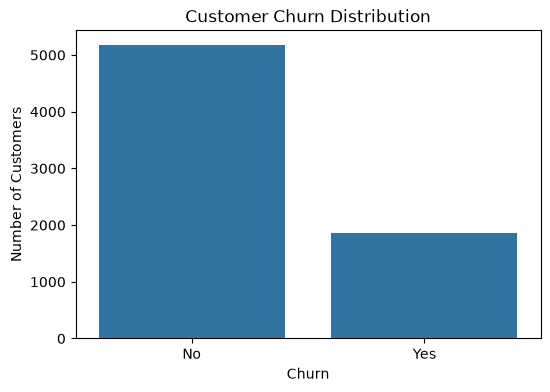

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

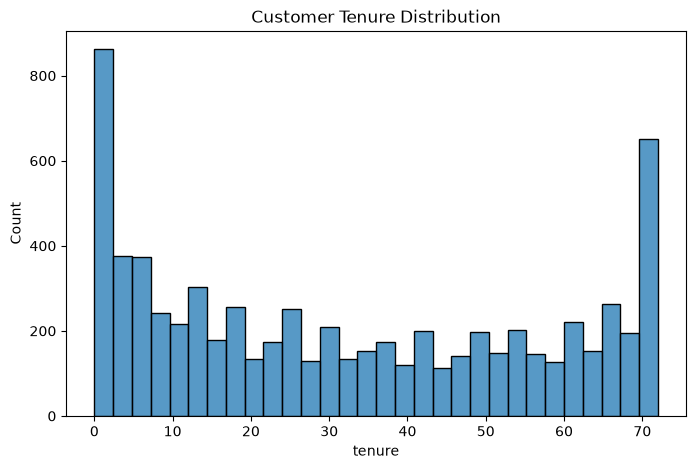

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30)
plt.title("Customer Tenure Distribution")
plt.show()

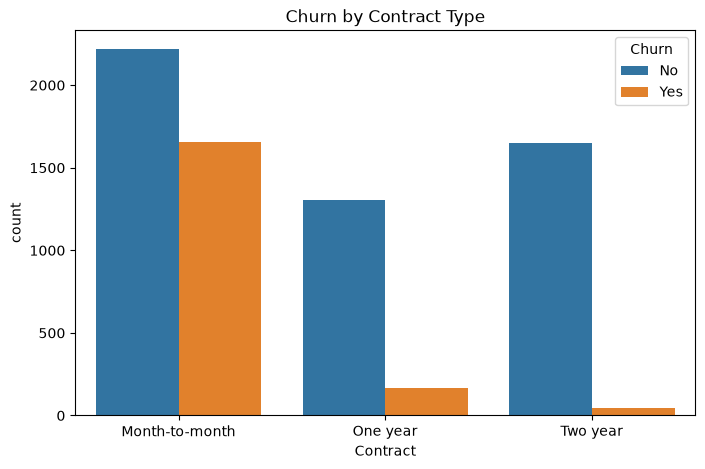

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.show()

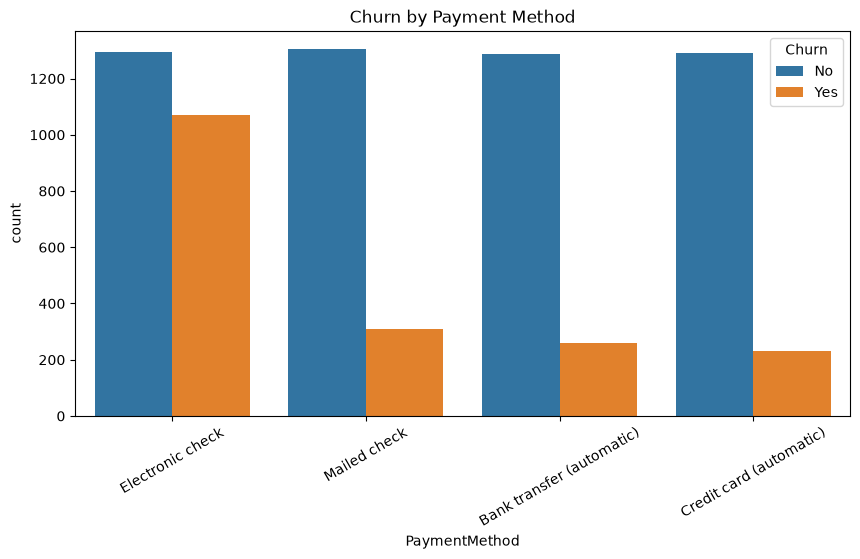

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=30)
plt.title("Churn by Payment Method")
plt.show()

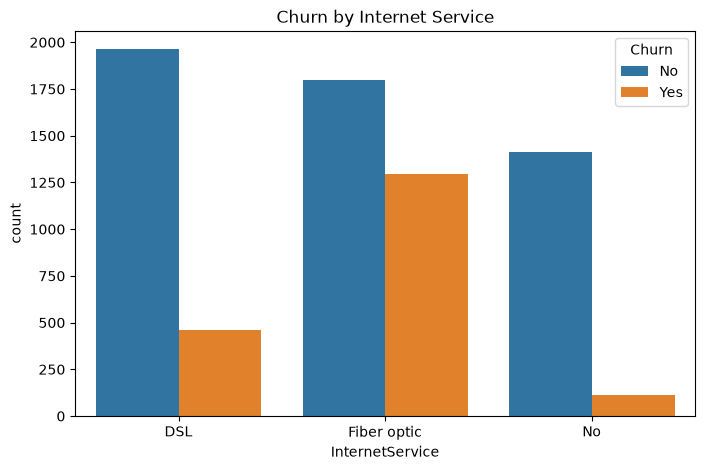

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Churn by Internet Service")
plt.show()

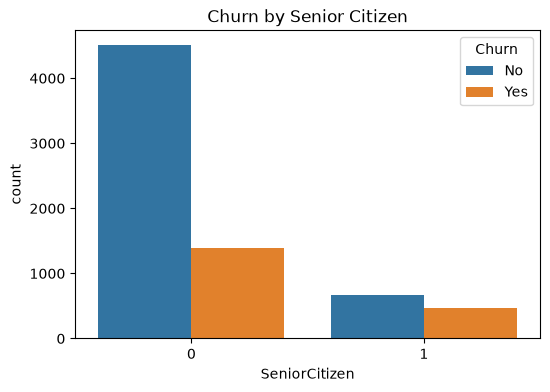

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Churn by Senior Citizen")
plt.show()

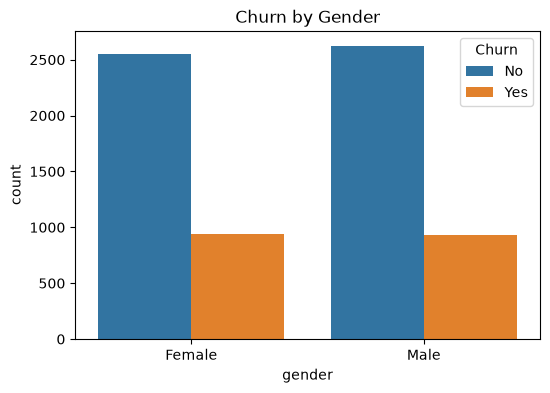

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Churn by Gender")
plt.show()

**Models**

In [19]:
df = df.drop("customerID", axis=1)

In [20]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df = df.dropna()

In [21]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [22]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

C:\Users\Hp\AppData\Local\Temp\ipykernel_17060\2852344203.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


            Feature  Importance
0          Contract    0.442558
2    OnlineSecurity    0.151151
3   InternetService    0.108614
4            tenure    0.080061
1       TechSupport    0.064040
6   StreamingMovies    0.058352
7     MultipleLines    0.049908
5  PaperlessBilling    0.045316


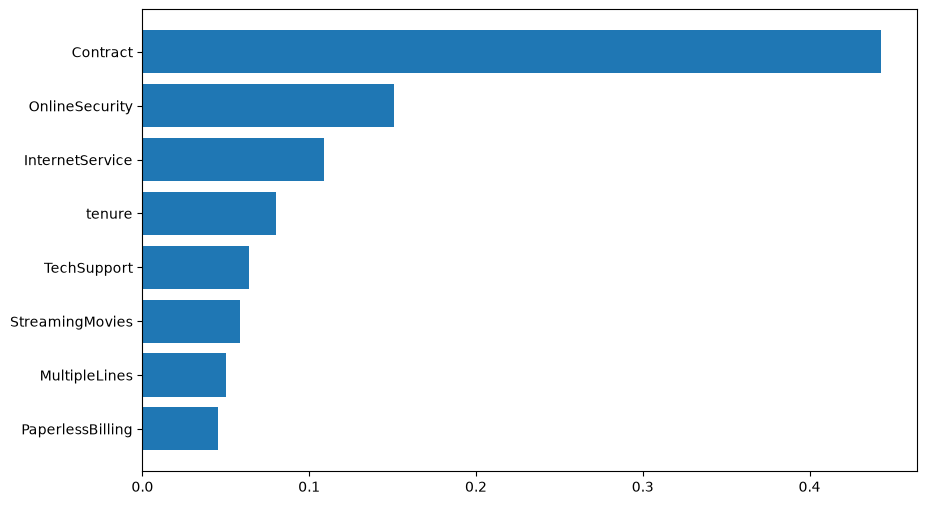

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Load the trained model if it is not already available in the notebook namespace
try:
    model
except NameError:
    model = joblib.load("model.pkl")

importance = model.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feat_imp = feat_imp.sort_values(
    by="Importance",
    ascending=False
)

print(feat_imp)

plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.show()


In [36]:
feat_imp.sort_values(
    by="Importance",
    ascending=False
).head(8)

,Feature,Importance
0,Contract,0.442558
2,OnlineSecurity,0.151151
3,InternetService,0.108614
4,tenure,0.080061
1,TechSupport,0.064040
6,StreamingMovies,0.058352
7,MultipleLines,0.049908
5,PaperlessBilling,0.045316


In [25]:
important_features = [
    "Contract",
    "TechSupport",
    "OnlineSecurity",
    "InternetService",
    "tenure",
    "PaperlessBilling",
    "StreamingMovies",
    "MultipleLines"
]

In [26]:
X = df[important_features]
y = df["Churn"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Logistic Regression**

In [29]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7697228144989339


**Random Forest**

In [30]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7789623312011372


**XGBoost**

In [31]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.775408670931059
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.51      0.55       374

    accuracy                           0.78      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



**Compare Models**

In [32]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():
    pred = model.predict(X_test)
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, pred))


 Logistic Regression
Accuracy: 0.7697228144989339

 Random Forest
Accuracy: 0.7789623312011372

 XGBoost
Accuracy: 0.775408670931059


**Feature Importance (XGBoost)**

In [33]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
0,Contract,0.442558
2,OnlineSecurity,0.151151
3,InternetService,0.108614
4,tenure,0.080061
1,TechSupport,0.064040
6,StreamingMovies,0.058352
7,MultipleLines,0.049908
5,PaperlessBilling,0.045316


In [34]:
X_train.shape

(5625, 8)

In [37]:
import joblib

joblib.dump(xgb, "model.pkl")

['model.pkl']

In [38]:
# Save model with metadata (model + feature columns)
import joblib

model_package = {
    "model": xgb,
    "feature_columns": X.columns.tolist()
}

joblib.dump(model_package, "xgb_model_with_meta.pkl")
print("Saved model package to: xgb_model_with_meta.pkl")

# Helper inference function

def predict_from_dataframe(df_input):
    X_input = df_input[model_package["feature_columns"]]
    return model_package["model"].predict(X_input)


Saved model package to: xgb_model_with_meta.pkl


In [40]:
# تحقق من أن النموذج موجود
import os
print("Model exists:", os.path.exists("model.pkl"))

# تحقق من المنفذ
import socket
sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
result = sock.connect_ex(('127.0.0.1', 5000))
if result == 0:
    print("Port 5000 is OPEN")
else:
    print("Port 5000 is CLOSED - Server not running")
sock.close()

Model exists: True
Port 5000 is CLOSED - Server not running
